In [1]:
import pandas as pd
# Define activities with durations(weeks) and dependencies

activities = {
    'A': {'name': 'Site Assessment', 'duration': 2, 'depends': []},
    'B': {'name': 'Master Plan Development', 'duration': 4, 'depends': ['A']},
    'C': {'name': 'Energy/Water/Demand Estimation', 'duration': 2, 'depends': ['B']},
    'D': {'name': 'Feasibility Study', 'duration': 3, 'depends': ['B']},
    'E': {'name': 'Excavation and Earthworks', 'duration': 4, 'depends': ['D']},
    'F': {'name': 'Building Construction', 'duration': 24, 'depends': ['E']},
    'G': {'name': 'River and Lake Installation', 'duration': 6, 'depends': ['E']},
    'H': {'name': 'Vertical Garden Setup', 'duration': 8, 'depends': ['F']},
    'I': {'name': 'Transportation Facility Construction', 'duration': 8, 'depends': ['E']},
    'J': {'name': 'Solar Panel Site Selection', 'duration': 2, 'depends': ['B']},
    'K': {'name': 'Solar Panel Installation', 'duration': 8, 'depends': ['J', 'F']},
    'L': {'name': 'Inverter and Wiring Setup', 'duration': 4, 'depends': ['K']},
    'M': {'name': 'Battery Storage Integration', 'duration': 4, 'depends': ['L']},
    'N': {'name': 'Grid Connection', 'duration': 2, 'depends': ['M']},
    'O': {'name': 'Water Treatment Plant Design', 'duration': 4, 'depends': ['D']},
    'P': {'name': 'Water Intake System', 'duration': 4, 'depends': ['O']},
    'Q': {'name': 'Pre-Treatment Installation', 'duration': 4, 'depends': ['P']},
    'R': {'name': 'Reverse Osmosis System', 'duration': 6, 'depends': ['Q']},
    'S': {'name': 'Post-Treatment and Storage', 'duration': 4, 'depends': ['R']},
    'T': {'name': 'Distribution Network', 'duration': 4, 'depends': ['S', 'G']},
    'U': {'name': 'System Integration', 'duration': 4, 'depends': ['N', 'T', 'I']},
    'V': {'name': 'Initial Testing (Energy)', 'duration': 2, 'depends': ['N']},
    'W': {'name': 'Initial Testing (Water)', 'duration': 2, 'depends': ['T']},
    'X': {'name': 'Transportation Testing', 'duration': 2, 'depends': ['I', 'U']},
    'Y': {'name': 'Ecosystem Validation', 'duration': 4, 'depends': ['T', 'H']},
    'Z': {'name': 'Landscaping and Aesthetics', 'duration': 4, 'depends': ['G', 'Y']},
    'AA': {'name': 'Safety and Accessibility', 'duration': 2, 'depends': ['F', 'I', 'Z']},
    'AB': {'name': 'Final Inspections', 'duration': 2, 'depends': ['U', 'V', 'W', 'X', 'AA']},
    'AC': {'name': 'Commissioning', 'duration': 1, 'depends': ['AB']},
    'AD': {'name': 'Maintenance Plan', 'duration': 2, 'depends': ['AC']}
}
# Convert the dictionary to DataFrame
activities_df = pd.DataFrame(activities).T.reset_index()
# Rename the 'index' column to 'Activity'
activities_df = activities_df.rename(columns={"index": "Activity"})
# Save the DataFrame to a CSV file
activities_df.to_csv('activity_table.csv', index=False)

# CPM Analysis and Network Diagram

In [2]:
import networkx as nx

# CPM Calculation
def calculate_cpm(activities):
    G = nx.DiGraph()
    for act, info in activities.items():
        G.add_node(act, duration=info['duration'])
        for dep in info['depends']:
            G.add_edge(dep, act)

    # Forward Pass
    for node in nx.topological_sort(G):
        predecessors = list(G.predecessors(node))
        if not predecessors:
            G.nodes[node]['ES'] = 0
            G.nodes[node]['EF'] = G.nodes[node]['duration']
        else:
            G.nodes[node]['ES'] = max(G.nodes[pred]['EF'] for pred in predecessors)
            G.nodes[node]['EF'] = G.nodes[node]['ES'] + G.nodes[node]['duration']

    # Backward Pass
    end_nodes = [n for n, d in G.out_degree() if d == 0]
    print(f'end_nodes :{end_nodes}')

    project_duration = max(G.nodes[n]['EF'] for n in end_nodes)

    for node in reversed(list(nx.topological_sort(G))):
        successors = list(G.successors(node))
        if not successors:
            G.nodes[node]['LF'] = project_duration
            G.nodes[node]['LS'] = G.nodes[node]['LF'] - G.nodes[node]['duration']
        else:
            G.nodes[node]['LF'] = min(G.nodes[succ]['LS'] for succ in successors)
            G.nodes[node]['LS'] = G.nodes[node]['LF'] - G.nodes[node]['duration']

    # Critical Path
    critical_path = [n for n in G.nodes if G.nodes[n]['ES'] == G.nodes[n]['LS']]
    return G, critical_path, project_duration
G, critical_path, project_duration = calculate_cpm(activities)
print(f"Project Duration: {project_duration} weeks")
print(f"Critical Path: {critical_path}")

end_nodes :['C', 'AD']
Project Duration: 66 weeks
Critical Path: ['A', 'B', 'D', 'E', 'F', 'K', 'L', 'M', 'N', 'U', 'X', 'AB', 'AC', 'AD']


Generate a cpm_table

In [3]:
import pandas as pd

def generate_cpm_table(G, critical_path):
    data = []
    for node in G.nodes:
        data.append({
            'Activity': node,
            'Description': activities[node]['name'],
            'Duration': G.nodes[node]['duration'],
            'ES': G.nodes[node]['ES'],
            'EF': G.nodes[node]['EF'],
            'LS': G.nodes[node]['LS'],
            'LF': G.nodes[node]['LF'],
            'Slack': G.nodes[node]['LS'] - G.nodes[node]['ES'],
            'Critical': 'Yes' if node in critical_path else 'No'
        })
    df = pd.DataFrame(data)
    df = df.sort_values(by='ES')  # Optional: sort by start time
    return df

# Generate the table
cpm_table = generate_cpm_table(G, critical_path)

# Save the table to a CSV file
cpm_table.to_csv('cpm_table.csv', index=False)

# Display the table
# print(cpm_table.to_string(index=False))


create a structure of the Network diagram

In [4]:
def compute_layered_positions(G, layer_gap=3.0, node_gap=4.0):
    """
    Compute positions for a directed acyclic graph (DAG) using layered layout.
    Nodes are assigned levels topologically and spaced evenly horizontally within each level.
    """
    # Step 1: Topological sort of nodes
    topo_order = list(nx.topological_sort(G))

    # Step 2: Assign levels based on longest path from source
    level_dict = {}
    for node in topo_order:
        preds = list(G.predecessors(node))
        level_dict[node] = 0 if not preds else max(level_dict[p] + 1 for p in preds)

    # Step 3: Group nodes by level
    levels = {}
    for node, level in level_dict.items():
        levels.setdefault(level, []).append(node)

    # Step 4: Assign positions
    pos = {}
    max_width = max(len(nodes) for nodes in levels.values())

    for level, nodes in levels.items():
        count = len(nodes)
        # Center the nodes at each level
        x_start = -((count - 1) * node_gap) / 2
        for i, node in enumerate(nodes):
            x = x_start + i * node_gap
            y = -level * layer_gap
            pos[node] = (x, y)

    return pos


Draw Network diagram and save it as cpm_diagram.png


In [8]:
import matplotlib.pyplot as plt

def draw_network_diagram(G, critical_path,filename="network_diagram.png"):
    plt.figure(figsize=(18, 24))
    # pos = nx.spring_layout(G, k=1.2, iterations=100, seed=42)
    pos = compute_layered_positions(G)

    # pos = compute_layered_positions(G, layer_gap=3.0, node_gap=14)

    node_colors = ['tomato' if n in critical_path else 'skyblue' for n in G.nodes]
    labels = {
        n: f"{n}\nES:{G.nodes[n]['ES']} EF:{G.nodes[n]['EF']}\nLS:{G.nodes[n]['LS']} LF:{G.nodes[n]['LF']}"
        for n in G.nodes
    }

    # Draw network
    nx.draw(G, pos, with_labels=False, arrows=True, node_size=5000, node_color=node_colors, edge_color='gray')
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_family="monospace")

    # # Optional: draw edge weights if needed
    # edge_labels = {(u, v): '' for u, v in G.edges}
    # nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=20)

    plt.title("Project Network Diagram with Critical Path Highlighted", fontsize=16)
    plt.axis('off')
    plt.tight_layout()


    plt.savefig(filename, dpi=300)
    print(f"Diagram saved as '{filename}'")

    plt.show()

# draw_network_diagram(G, critical_path, filename="cpm_diagram.png")


# ACT_CRASHING

In [ ]:
# # Complete activity data with normal and crash information (in $M)
# activities = {
#     'A': {'name': 'Site Assessment', 'normal_duration': 2, 'normal_cost': 0.023, 'crash_duration': 1, 'crash_cost': 0.025, 'depends': []},
#     'B': {'name': 'Master Plan Development', 'normal_duration': 4, 'normal_cost': 0.115, 'crash_duration': 3, 'crash_cost': 0.125, 'depends': ['A']},
#     'C': {'name': 'Energy/Water Demand Estimation', 'normal_duration': 2, 'normal_cost': 0.012, 'crash_duration': 1, 'crash_cost': 0.014, 'depends': ['B']},
#     'D': {'name': 'Feasibility Study', 'normal_duration': 3, 'normal_cost': 0.092, 'crash_duration': 2, 'crash_cost': 0.102, 'depends': ['B']},
#     'E': {'name': 'Excavation and Earthworks', 'normal_duration': 4, 'normal_cost': 0.23, 'crash_duration': 3, 'crash_cost': 0.25, 'depends': ['D']},
#     'F': {'name': 'Building Construction', 'normal_duration': 24, 'normal_cost': 575, 'crash_duration': 20, 'crash_cost': 575.2, 'depends': ['E']},
#     'G': {'name': 'River and Lake Installation', 'normal_duration': 6, 'normal_cost': 2.01, 'crash_duration': 5, 'crash_cost': 2.03, 'depends': ['E']},
#     'H': {'name': 'Vertical Garden Setup', 'normal_duration': 8, 'normal_cost': 1.15, 'crash_duration': 6, 'crash_cost': 1.17, 'depends': ['F']},
#     'I': {'name': 'Transportation Facility Construction', 'normal_duration': 8, 'normal_cost': 2.3, 'crash_duration': 6, 'crash_cost': 2.32, 'depends': ['E']},
#     'J': {'name': 'Solar Panel Site Selection', 'normal_duration': 2, 'normal_cost': 0.012, 'crash_duration': 1, 'crash_cost': 0.014, 'depends': ['B']},
#     'K': {'name': 'Solar Panel Installation', 'normal_duration': 8, 'normal_cost': 5.75, 'crash_duration': 6, 'crash_cost': 5.79, 'depends': ['J', 'F']},
#     'L': {'name': 'Inverter and Wiring Setup', 'normal_duration': 4, 'normal_cost': 0.115, 'crash_duration': 3, 'crash_cost': 0.125, 'depends': ['K']},
#     'M': {'name': 'Battery Storage Integration', 'normal_duration': 4, 'normal_cost': 0.115, 'crash_duration': 3, 'crash_cost': 0.125, 'depends': ['L']},
#     'N': {'name': 'Grid Connection', 'normal_duration': 2, 'normal_cost': 0.0575, 'crash_duration': 1, 'crash_cost': 0.0625, 'depends': ['M']},
#     'O': {'name': 'Water Treatment Plant Design', 'normal_duration': 4, 'normal_cost': 0.092, 'crash_duration': 3, 'crash_cost': 0.102, 'depends': ['D']},
#     'P': {'name': 'Water Intake System', 'normal_duration': 4, 'normal_cost': 0.115, 'crash_duration': 3, 'crash_cost': 0.125, 'depends': ['O']},
#     'Q': {'name': 'Pre-Treatment Installation', 'normal_duration': 4, 'normal_cost': 0.115, 'crash_duration': 3, 'crash_cost': 0.125, 'depends': ['P']},
#     'R': {'name': 'Reverse Osmosis System', 'normal_duration': 6, 'normal_cost': 0.1725, 'crash_duration': 4, 'crash_cost': 0.2025, 'depends': ['Q']},
#     'S': {'name': 'Post-Treatment and Storage', 'normal_duration': 4, 'normal_cost': 0.115, 'crash_duration': 3, 'crash_cost': 0.125, 'depends': ['R']},
#     'T': {'name': 'Distribution Network', 'normal_duration': 4, 'normal_cost': 0.1725, 'crash_duration': 3, 'crash_cost': 0.1825, 'depends': ['S', 'G']},
#     'U': {'name': 'System Integration', 'normal_duration': 4, 'normal_cost': 0.23, 'crash_duration': 3, 'crash_cost': 0.25, 'depends': ['N', 'T', 'I']},
#     'V': {'name': 'Initial Testing (Energy)', 'normal_duration': 2, 'normal_cost': 0.012, 'crash_duration': 1, 'crash_cost': 0.014, 'depends': ['N']},
#     'W': {'name': 'Initial Testing (Water)', 'normal_duration': 2, 'normal_cost': 0.012, 'crash_duration': 1, 'crash_cost': 0.014, 'depends': ['T']},
#     'X': {'name': 'Transportation Testing', 'normal_duration': 2, 'normal_cost': 0.012, 'crash_duration': 1, 'crash_cost': 0.014, 'depends': ['I', 'U']},
#     'Y': {'name': 'Ecosystem Validation', 'normal_duration': 4, 'normal_cost': 0.115, 'crash_duration': 3, 'crash_cost': 0.125, 'depends': ['T', 'H']},
#     'Z': {'name': 'Landscaping and Aesthetics', 'normal_duration': 4, 'normal_cost': 0.1725, 'crash_duration': 3, 'crash_cost': 0.1825, 'depends': ['G', 'Y']},
#     'AA': {'name': 'Safety and Accessibility', 'normal_duration': 2, 'normal_cost': 0.012, 'crash_duration': 1, 'crash_cost': 0.014, 'depends': ['F', 'I', 'Z']},
#     'AB': {'name': 'Final Inspections', 'normal_duration': 2, 'normal_cost': 0.012, 'crash_duration': 1, 'crash_cost': 0.014, 'depends': ['U', 'V', 'W', 'X', 'AA']},
#     'AC': {'name': 'Commissioning', 'normal_duration': 1, 'normal_cost': 0.012, 'crash_duration': 1, 'crash_cost': 0.014, 'depends': ['AB']},
#     'AD': {'name': 'Maintenance Plan', 'normal_duration': 2, 'normal_cost': 0.012, 'crash_duration': 1, 'crash_cost': 0.014, 'depends': ['AC']}
# }
# df = pd.DataFrame(activities)
# # df.to_csv('project_activities_details.csv', index=True)
# # df['A']['crash_duration']
# # df



In [35]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

# Activity data
data = {
    'Activity ID': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'AA', 'AB', 'AC', 'AD'],
    'Activity Name': [
        'Site Assessment', 'Master Plan Development', 'Energy/Water Demand Estimation', 'Feasibility Study', 'Excavation and Earthworks', 'Building Construction',
        'River and Lake Installation', 'Vertical Garden Setup', 'Transportation Facility Construction', 'Solar Panel Site Selection', 'Solar Panel Installation',
        'Inverter and Wiring Setup', 'Battery Storage Integration', 'Grid Connection', 'Water Treatment Plant Design', 'Water Intake System', 'Pre-Treatment Installation',
        'Reverse Osmosis System', 'Post-Treatment and Storage', 'Distribution Network', 'System Integration', 'Initial Testing (Energy)', 'Initial Testing (Water)',
        'Transportation Testing', 'Ecosystem Validation', 'Landscaping and Aesthetics', 'Safety and Accessibility', 'Final Inspections', 'Commissioning', 'Maintenance Plan'
    ],
    'Normal Duration (Weeks)': [2, 4, 2, 3, 4, 24, 6, 8, 8, 2, 8, 4, 4, 2, 4, 4, 4, 6, 4, 4, 4, 2, 2, 2, 4, 4, 2, 2, 1, 2],
    'Crash Duration (Weeks)': [1, 3, 1, 2, 3, 20, 5, 6, 6, 1, 6, 3, 3, 1, 3, 3, 3, 4, 3, 3, 3, 1, 1, 1, 3, 3, 1, 1, 1, 1],
    'Direct Costs ($M)': [0.02, 0.1, 0.01, 0.08, 0.2, 500, 1.75, 1, 2, 0.01, 5, 0.1, 0.1, 0.05, 0.08, 0.1, 0.1, 0.15, 0.1, 0.15, 0.2, 0.01, 0.01, 0.01, 0.1, 0.15, 0.01, 0.01, 0.01, 0.01],
    'Overhead/Indirect Costs ($M)': [0.003, 0.015, 0.002, 0.012, 0.03, 75, 0.26, 0.15, 0.3, 0.002, 0.75, 0.015, 0.015, 0.0075, 0.012, 0.015, 0.015, 0.0225, 0.015, 0.0225, 0.03, 0.002, 0.002, 0.002, 0.015, 0.0225, 0.002, 0.002, 0.002, 0.002],
    'Normal Cost ($M)': [0.023, 0.115, 0.012, 0.092, 0.23, 575, 2.01, 1.15, 2.3, 0.012, 5.75, 0.115, 0.115, 0.0575, 0.092, 0.115, 0.115, 0.1725, 0.115, 0.1725, 0.23, 0.012, 0.012, 0.012, 0.115, 0.1725, 0.012, 0.012, 0.012, 0.012],
    'Crash Cost ($M)': [0.025, 0.125, 0.014, 0.102, 0.25, 575.2, 2.03, 1.17, 2.32, 0.014, 5.79, 0.125, 0.125, 0.0625, 0.102, 0.125, 0.125, 0.2025, 0.125, 0.1825, 0.25, 0.014, 0.014, 0.014, 0.125, 0.1825, 0.014, 0.014, 0.014, 0.014],
    'Resource Demand (Workers)': [5, 10, 5, 8, 20, 50, 15, 10, 15, 5, 20, 10, 10, 5, 8, 10, 10, 15, 10, 15, 20, 5, 5, 5, 10, 15, 5, 5, 5, 5]
}

# Create DataFrame and save to CSV
df = pd.DataFrame(data)
# df.to_csv('project_data_details.csv', index=False)

# Convert durations to days (1 week = 7 days)
df['Normal Duration (Days)'] = df['Normal Duration (Weeks)'] * 7
df['Crash Duration (Days)'] = df['Crash Duration (Weeks)'] * 7

# Calculate crash slope (incremental cost per day in $M)
df['Crash Slope ($/Day)'] = ((df['Crash Cost ($M)'] - df['Normal Cost ($M)']) / ((df['Normal Duration (Weeks)'] * 7 - df['Crash Duration (Weeks)'] * 7) / 7) * 1000000).round(2)

# Create activities dictionary with dependencies
dependencies = {
    'A': [], 'B': ['A'], 'C': ['B'], 'D': ['B'], 'E': ['D'], 'F': ['E'], 'G': ['E'], 'H': ['F'], 'I': ['E'], 'J': ['B'],
    'K': ['J', 'F'], 'L': ['K'], 'M': ['L'], 'N': ['M'], 'O': ['D'], 'P': ['O'], 'Q': ['P'], 'R': ['Q'], 'S': ['R'],
    'T': ['S', 'G'], 'U': ['N', 'T', 'I'], 'V': ['N'], 'W': ['T'], 'X': ['I', 'U'], 'Y': ['T', 'H'], 'Z': ['G', 'Y'],
    'AA': ['F', 'I', 'Z'], 'AB': ['U', 'V', 'W', 'X', 'AA'], 'AC': ['AB'], 'AD': ['AC']
}
activities = {row['Activity ID']: {
    'name': row['Activity Name'],
    'normal_duration': row['Normal Duration (Days)'],
    'crash_duration': row['Crash Duration (Days)'],
    'normal_cost': row['Normal Cost ($M)'],
    'crash_cost': row['Crash Cost ($M)'],
    'depends': dependencies[row['Activity ID']],
    'crash_slope': row['Crash Slope ($/Day)'] if pd.notna(row['Crash Slope ($/Day)']) else float('inf')
} for _, row in df.iterrows()}
activities



{'A': {'name': 'Site Assessment',
  'normal_duration': 14,
  'crash_duration': 7,
  'normal_cost': 0.023,
  'crash_cost': 0.025,
  'depends': [],
  'crash_slope': 2000.0},
 'B': {'name': 'Master Plan Development',
  'normal_duration': 28,
  'crash_duration': 21,
  'normal_cost': 0.115,
  'crash_cost': 0.125,
  'depends': ['A'],
  'crash_slope': 10000.0},
 'C': {'name': 'Energy/Water Demand Estimation',
  'normal_duration': 14,
  'crash_duration': 7,
  'normal_cost': 0.012,
  'crash_cost': 0.014,
  'depends': ['B'],
  'crash_slope': 2000.0},
 'D': {'name': 'Feasibility Study',
  'normal_duration': 21,
  'crash_duration': 14,
  'normal_cost': 0.092,
  'crash_cost': 0.102,
  'depends': ['B'],
  'crash_slope': 10000.0},
 'E': {'name': 'Excavation and Earthworks',
  'normal_duration': 28,
  'crash_duration': 21,
  'normal_cost': 0.23,
  'crash_cost': 0.25,
  'depends': ['D'],
  'crash_slope': 20000.0},
 'F': {'name': 'Building Construction',
  'normal_duration': 168,
  'crash_duration': 140

In [36]:
import networkx as nx

# CPM Calculation
def calculate_cpm(activities):
    G = nx.DiGraph()
    for act, info in activities.items():
        G.add_node(act, duration=info['normal_duration'])
        for dep in info['depends']:
            G.add_edge(dep, act)

    # Forward Pass
    for node in nx.topological_sort(G):
        predecessors = list(G.predecessors(node))
        if not predecessors:
            G.nodes[node]['ES'] = 0
            G.nodes[node]['EF'] = G.nodes[node]['duration']
        else:
            G.nodes[node]['ES'] = max(G.nodes[pred]['EF'] for pred in predecessors)
            G.nodes[node]['EF'] = G.nodes[node]['ES'] + G.nodes[node]['duration']

    # Backward Pass
    end_nodes = [n for n, d in G.out_degree() if d == 0]
    # print(f'end_nodes :{end_nodes}')

    project_duration = max(G.nodes[n]['EF'] for n in end_nodes)

    for node in reversed(list(nx.topological_sort(G))):
        successors = list(G.successors(node))
        if not successors:
            G.nodes[node]['LF'] = project_duration
            G.nodes[node]['LS'] = G.nodes[node]['LF'] - G.nodes[node]['duration']
        else:
            G.nodes[node]['LF'] = min(G.nodes[succ]['LS'] for succ in successors)
            G.nodes[node]['LS'] = G.nodes[node]['LF'] - G.nodes[node]['duration']

    # Critical Path
    critical_path = [n for n in G.nodes if G.nodes[n]['ES'] == G.nodes[n]['LS']]
    return G, critical_path, project_duration
G, critical_path, project_duration = calculate_cpm(activities)
print(f"Project Duration: {project_duration} weeks")
print(f"Critical Path: {critical_path}")

Project Duration: 462 weeks
Critical Path: ['A', 'B', 'D', 'E', 'F', 'K', 'L', 'M', 'N', 'U', 'X', 'AB', 'AC', 'AD']


In [37]:
# # Generate cost curve with crashing
# def generate_cost_curve(activities, indirect_cost_savings_per_day=142857 / 1000000, penalty_per_day=50000 / 1000000):
#     G, critical_path, normal_duration = calculate_cpm(activities)
#     initial_cost = sum(info['normal_cost'] for info in activities.values())  # 587.35M
#     original_durations = {act: info['normal_duration'] for act, info in activities.items()}


#     # Set all to crash duration for least duration
#     for act in activities:
#         activities[act]['normal_duration'] = activities[act]['crash_duration']
#     _, _, least_duration = calculate_cpm(activities)

#     # Restore and crash incrementally
#     duration_history = [normal_duration]
#     total_cost_history = [initial_cost]
#     current_cost = initial_cost
#     days_crashed = 0
#     optimum_cost = initial_cost
#     optimum_duration = normal_duration
#     optimum_critical_activities = []

#     for act in activities:
#         activities[act]['normal_duration'] = original_durations[act]
#     G, critical_path, current_duration = calculate_cpm(activities)

#     while current_duration > least_duration:
#         crashable = [(act, activities[act]['crash_slope']) for act in critical_path if activities[act]['normal_duration'] > activities[act]['crash_duration']]
#         if not crashable:
#             break
#         act_to_crash = min(crashable, key=lambda x: x[1])[0]
#         crash_days = min(1, activities[act_to_crash]['normal_duration'] - activities[act_to_crash]['crash_duration'])
#         crash_cost_increase = crash_days * (activities[act_to_crash]['crash_slope'] / 1000000)
#         indirect_savings = crash_days * indirect_cost_savings_per_day
#         penalty = days_crashed * penalty_per_day if days_crashed > 28 else 0
#         current_cost += crash_cost_increase - indirect_savings + penalty
#         if current_cost < optimum_cost:
#             optimum_cost = current_cost
#             optimum_duration = current_duration
#             optimum_critical_activities = critical_path[:]
#         activities[act_to_crash]['normal_duration'] -= crash_days
#         days_crashed += crash_days
#         G, critical_path, current_duration = calculate_cpm(activities)
#         duration_history.append(current_duration)
#         total_cost_history.append(current_cost)

#     # Restore to normal and add delay (optional)
#     for act in activities:
#         activities[act]['normal_duration'] = original_durations[act]
#     G, critical_path, current_duration = calculate_cpm(activities)
#     while current_duration < normal_duration:
#         current_duration += 1
#         total_cost_history.append(current_cost)  # No further crashing, just delay
#         duration_history.append(current_duration)
#     print(f"Critical Activities at Optimum Cost-Duration: {optimum_critical_activities}")  # Print the activities
#     return duration_history, total_cost_history, optimum_duration, optimum_cost, least_duration, initial_cost, normal_duration # Added normal_duration to the return statement


In [38]:
import pandas as pd

def generate_cost_curve(activities, indirect_cost_savings_per_day=142857 / 1000000, penalty_per_day=50000 / 1000000):
    # Calculate initial CPM data
    G, critical_path, normal_duration = calculate_cpm(activities)
    initial_cost = sum(info['normal_cost'] for info in activities.values())
    original_durations = {act: info['normal_duration'] for act, info in activities.items()}

    # Get least possible duration by fully crashing
    for act in activities:
        activities[act]['normal_duration'] = activities[act]['crash_duration']
    _, _, least_duration = calculate_cpm(activities)

    # Restore normal durations
    for act in activities:
        activities[act]['normal_duration'] = original_durations[act]

    # Initialize tracking variables
    G, critical_path, current_duration = calculate_cpm(activities)
    duration_history = [normal_duration]
    total_cost_history = [initial_cost]
    current_cost = initial_cost
    days_crashed = 0

    optimum_cost = initial_cost
    optimum_duration = normal_duration
    optimum_critical_activities = []
    optimum_activity_durations = {}
    crashing_order = []
    # Crashing loop
    while current_duration > least_duration:
        crashable = [
            (act, activities[act]['crash_slope'])
            for act in critical_path
            if activities[act]['normal_duration'] > activities[act]['crash_duration']
        ]
        if not crashable:
            break

        act_to_crash = min(crashable, key=lambda x: x[1])[0]
        crashing_order.append(act_to_crash)
        crash_days = min(1, activities[act_to_crash]['normal_duration'] - activities[act_to_crash]['crash_duration'])

        crash_cost_increase = crash_days * (activities[act_to_crash]['crash_slope'] / 1_000_000)
        indirect_savings = crash_days * indirect_cost_savings_per_day
        penalty = days_crashed * penalty_per_day if days_crashed > 28 else 0

        current_cost += crash_cost_increase - indirect_savings + penalty

        # Check if this is the lowest cost seen so far
        if current_cost < optimum_cost:
            optimum_cost = current_cost
            optimum_duration = current_duration
            optimum_critical_activities = critical_path[:]
            # Save the durations at this point
            optimum_activity_durations = {
                act: activities[act]['normal_duration'] for act in activities
            }

        # Apply crash
        activities[act_to_crash]['normal_duration'] -= crash_days
        days_crashed += crash_days

        # Recalculate CPM
        G, critical_path, current_duration = calculate_cpm(activities)
        duration_history.append(current_duration)
        total_cost_history.append(current_cost)

    # Optional delay simulation (keeping cost same, increasing duration)
    for act in activities:
        activities[act]['normal_duration'] = original_durations[act]
    G, critical_path, current_duration = calculate_cpm(activities)
    while current_duration < normal_duration:
        current_duration += 1
        total_cost_history.append(current_cost)
        duration_history.append(current_duration)

    print(f"Optimum Duration: {optimum_duration} days")
    print(f"Optimum Cost: ${optimum_cost:.2f}M")
    print(f"Critical Activities at Optimum Cost-Duration: {optimum_critical_activities}")

    # Build crash info DataFrame
    crashed_activities = []
    for act in activities:
        normal = original_durations[act]
        crashed = optimum_activity_durations.get(act, normal)
        if crashed < normal:
            crashed_activities.append({
                'Activity': act,
                'Normal Duration': normal,
                'Crashed Duration': crashed,
                'Days Crashed': normal - crashed
            })

    df_crashed = pd.DataFrame(crashed_activities)

    return duration_history, total_cost_history, optimum_duration, optimum_cost, least_duration, initial_cost, normal_duration, df_crashed,crashing_order


Optimum Duration: 434 days
Optimum Cost: $584.28M
Critical Activities at Optimum Cost-Duration: ['A', 'B', 'D', 'E', 'F', 'K', 'L', 'M', 'N', 'U', 'X', 'AB', 'AC', 'AD']
Crashing_order_Details: {'A': 7, 'X': 7, 'AB': 7, 'AD': 7, 'N': 7, 'B': 7, 'D': 7, 'L': 7, 'M': 7, 'E': 7, 'K': 14, 'AA': 7, 'U': 7, 'H': 1, 'F': 28}
Normal Duration: 462 days, Normal Cost: $588.36M
Optimum Duration or Least cost duration: 434 days, Optimum Cost: $584.28M
Least Duration: 343 days, Least Cost: $952.33M


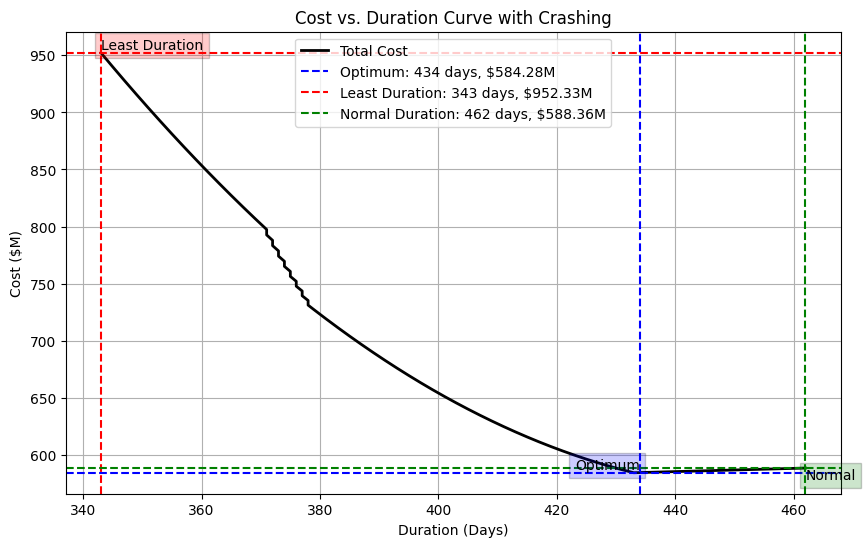

,Activity,Normal Duration,Crashed Duration,Days Crashed
0,A,14,7,7
1,X,14,7,7
2,AB,14,7,7
3,AD,14,7,7


In [45]:

# Run curve generation
duration_history, total_cost_history, optimum_duration, optimum_cost, least_duration, initial_cost, normal_duration, df_crashed,crashing_order  = generate_cost_curve(activities) # Added normal_duration to capture the returned value

crashed_dict = Counter(crashing_order)
# Convert counts to crash days
crashed_dict = {act: days for act, days in crashed_dict.items()}
print("Crashing_order_Details:", crashed_dict)


# print("Crashing Order:", crashing_order)  # Print the order
print(f"Normal Duration: {normal_duration} days, Normal Cost: ${normal_cost:.2f}M")
print(f"Optimum Duration or Least cost duration: {optimum_duration} days, Optimum Cost: ${optimum_cost:.2f}M")
print(f"Least Duration: {least_duration} days, Least Cost: ${total_cost_history[duration_history.index(least_duration)]:.2f}M")

# Plot the graph
plt.figure(figsize=(10, 6))
plt.plot(duration_history, total_cost_history, 'k-', label='Total Cost', linewidth=2)
plt.axvline(optimum_duration, color='b', linestyle='--', label=f'Optimum: {optimum_duration} days, ${optimum_cost:.2f}M')
plt.axvline(least_duration, color='r', linestyle='--', label=f'Least Duration: {least_duration} days, ${total_cost_history[duration_history.index(least_duration)]:.2f}M')
plt.axvline(normal_duration, color='g', linestyle='--', label=f'Normal Duration: {normal_duration} days, ${normal_cost:.2f}M')
plt.axhline(optimum_cost, color='b', linestyle='--')
plt.axhline(total_cost_history[duration_history.index(least_duration)], color='r', linestyle='--')
plt.axhline(normal_cost, color='g', linestyle='--')
plt.text(optimum_duration, optimum_cost, 'Optimum', bbox=dict(facecolor='blue', alpha=0.2), ha='right', va='bottom')
plt.text(least_duration, total_cost_history[duration_history.index(least_duration)], 'Least Duration', bbox=dict(facecolor='red', alpha=0.2), ha='left', va='bottom')
plt.text(normal_duration, normal_cost, 'Normal', bbox=dict(facecolor='green', alpha=0.2), ha='left', va='top')
plt.xlabel('Duration (Days)')
plt.ylabel('Cost ($M)')
plt.title('Cost vs. Duration Curve with Crashing')
plt.legend()
plt.grid(True)
plt.show()
df_crashed


In [47]:
# new_df
# df_crashed

# Resource leveling


In [52]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Activity data (same as provided)
data = {
    'Activity ID': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'AA', 'AB', 'AC', 'AD'],
    'Activity Name': [
        'Site Assessment', 'Master Plan Development', 'Energy/Water Demand Estimation', 'Feasibility Study', 'Excavation and Earthworks', 'Building Construction',
        'River and Lake Installation', 'Vertical Garden Setup', 'Transportation Facility Construction', 'Solar Panel Site Selection', 'Solar Panel Installation',
        'Inverter and Wiring Setup', 'Battery Storage Integration', 'Grid Connection', 'Water Treatment Plant Design', 'Water Intake System', 'Pre-Treatment Installation',
        'Reverse Osmosis System', 'Post-Treatment and Storage', 'Distribution Network', 'System Integration', 'Initial Testing (Energy)', 'Initial Testing (Water)',
        'Transportation Testing', 'Ecosystem Validation', 'Landscaping and Aesthetics', 'Safety and Accessibility', 'Final Inspections', 'Commissioning', 'Maintenance Plan'
    ],
    'Normal Duration (Weeks)': [2, 4, 2, 3, 4, 24, 6, 8, 8, 2, 8, 4, 4, 2, 4, 4, 4, 6, 4, 4, 4, 2, 2, 2, 4, 4, 2, 2, 1, 2],
    'Crash Duration (Weeks)': [1, 3, 1, 2, 3, 20, 5, 6, 6, 1, 6, 3, 3, 1, 3, 3, 3, 4, 3, 3, 3, 1, 1, 1, 3, 3, 1, 1, 1, 1],
    'Direct Costs ($M)': [0.02, 0.1, 0.01, 0.08, 0.2, 500, 1.75, 1, 2, 0.01, 5, 0.1, 0.1, 0.05, 0.08, 0.1, 0.1, 0.15, 0.1, 0.15, 0.2, 0.01, 0.01, 0.01, 0.1, 0.15, 0.01, 0.01, 0.01, 0.01],
    'Overhead/Indirect Costs ($M)': [0.003, 0.015, 0.002, 0.012, 0.03, 75, 0.26, 0.15, 0.3, 0.002, 0.75, 0.015, 0.015, 0.0075, 0.012, 0.015, 0.015, 0.0225, 0.015, 0.0225, 0.03, 0.002, 0.002, 0.002, 0.015, 0.0225, 0.002, 0.002, 0.002, 0.002],
    'Normal Cost ($M)': [0.023, 0.115, 0.012, 0.092, 0.23, 575, 2.01, 1.15, 2.3, 0.012, 5.75, 0.115, 0.115, 0.0575, 0.092, 0.115, 0.115, 0.1725, 0.115, 0.1725, 0.23, 0.012, 0.012, 0.012, 0.115, 0.1725, 0.012, 0.012, 0.012, 0.012],
    'Crash Cost ($M)': [0.025, 0.125, 0.014, 0.102, 0.25, 575.2, 2.03, 1.17, 2.32, 0.014, 5.79, 0.125, 0.125, 0.0625, 0.102, 0.125, 0.125, 0.2025, 0.125, 0.1825, 0.25, 0.014, 0.014, 0.014, 0.125, 0.1825, 0.014, 0.014, 0.014, 0.014],
    'Resource Demand (Workers)': [5, 10, 5, 8, 20, 50, 15, 10, 15, 5, 20, 10, 10, 5, 8, 10, 10, 15, 10, 15, 20, 5, 5, 5, 10, 15, 5, 5, 5, 5]
}

# Create DataFrame and save to CSV
df = pd.DataFrame(data)
# df.to_csv('project_data_details.csv', index=False)

# Convert durations to days
df['Normal Duration (Days)'] = df['Normal Duration (Weeks)'] * 7
df['Crash Duration (Days)'] = df['Crash Duration (Weeks)'] * 7

# Calculate crash slope
df['Crash Slope ($/Day)'] = ((df['Crash Cost ($M)'] - df['Normal Cost ($M)']) / ((df['Normal Duration (Weeks)'] * 7 - df['Crash Duration (Weeks)'] * 7) / 7) * 1000000).round(2)

# Create activities dictionary with dependencies
dependencies = {
    'A': [], 'B': ['A'], 'C': ['B'], 'D': ['B'], 'E': ['D'], 'F': ['E'], 'G': ['E'], 'H': ['F'], 'I': ['E'], 'J': ['B'],
    'K': ['J', 'F'], 'L': ['K'], 'M': ['L'], 'N': ['M'], 'O': ['D'], 'P': ['O'], 'Q': ['P'], 'R': ['Q'], 'S': ['R'],
    'T': ['S', 'G'], 'U': ['N', 'T', 'I'], 'V': ['N'], 'W': ['T'], 'X': ['I', 'U'], 'Y': ['T', 'H'], 'Z': ['G', 'Y'],
    'AA': ['F', 'I', 'Z'], 'AB': ['U', 'V', 'W', 'X', 'AA'], 'AC': ['AB'], 'AD': ['AC']
}
activities = {row['Activity ID']: {
    'name': row['Activity Name'],
    'normal_duration': row['Normal Duration (Days)'],
    'crash_duration': row['Crash Duration (Days)'],
    'normal_cost': row['Normal Cost ($M)'],
    'crash_cost': row['Crash Cost ($M)'],
    'depends': dependencies[row['Activity ID']],
    'crash_slope': row['Crash Slope ($/Day)'] if pd.notna(row['Crash Slope ($/Day)']) else float('inf'),
    'resources': row['Resource Demand (Workers)']
} for _, row in df.iterrows()}



In [53]:
# CPM Calculation
def calculate_cpm(activities):
    G = nx.DiGraph()
    for act, info in activities.items():
        G.add_node(act, duration=info['normal_duration'], resources=info['resources'])
        for dep in info['depends']:
            G.add_edge(dep, act)

    # Forward Pass
    for node in nx.topological_sort(G):
        predecessors = list(G.predecessors(node))
        if not predecessors:
            G.nodes[node]['ES'] = 0
            G.nodes[node]['EF'] = G.nodes[node]['duration']
        else:
            G.nodes[node]['ES'] = max(G.nodes[pred]['EF'] for pred in predecessors)
            G.nodes[node]['EF'] = G.nodes[node]['ES'] + G.nodes[node]['duration']

    # Backward Pass
    end_nodes = [n for n, d in G.out_degree() if d == 0]
    # print(f'end_nodes: {end_nodes}')
    project_duration = max(G.nodes[n]['EF'] for n in end_nodes)

    for node in reversed(list(nx.topological_sort(G))):
        successors = list(G.successors(node))
        if not successors:
            G.nodes[node]['LF'] = project_duration
            G.nodes[node]['LS'] = G.nodes[node]['LF'] - G.nodes[node]['duration']
        else:
            G.nodes[node]['LF'] = min(G.nodes[succ]['LS'] for succ in successors)
            G.nodes[node]['LS'] = G.nodes[node]['LF'] - G.nodes[node]['duration']

    # Critical Path
    critical_path = [n for n in G.nodes if G.nodes[n]['ES'] == G.nodes[n]['LS']]
    return G, critical_path, project_duration



Histogram of activties and time

Histogram saved as 'activity_histogram.png'


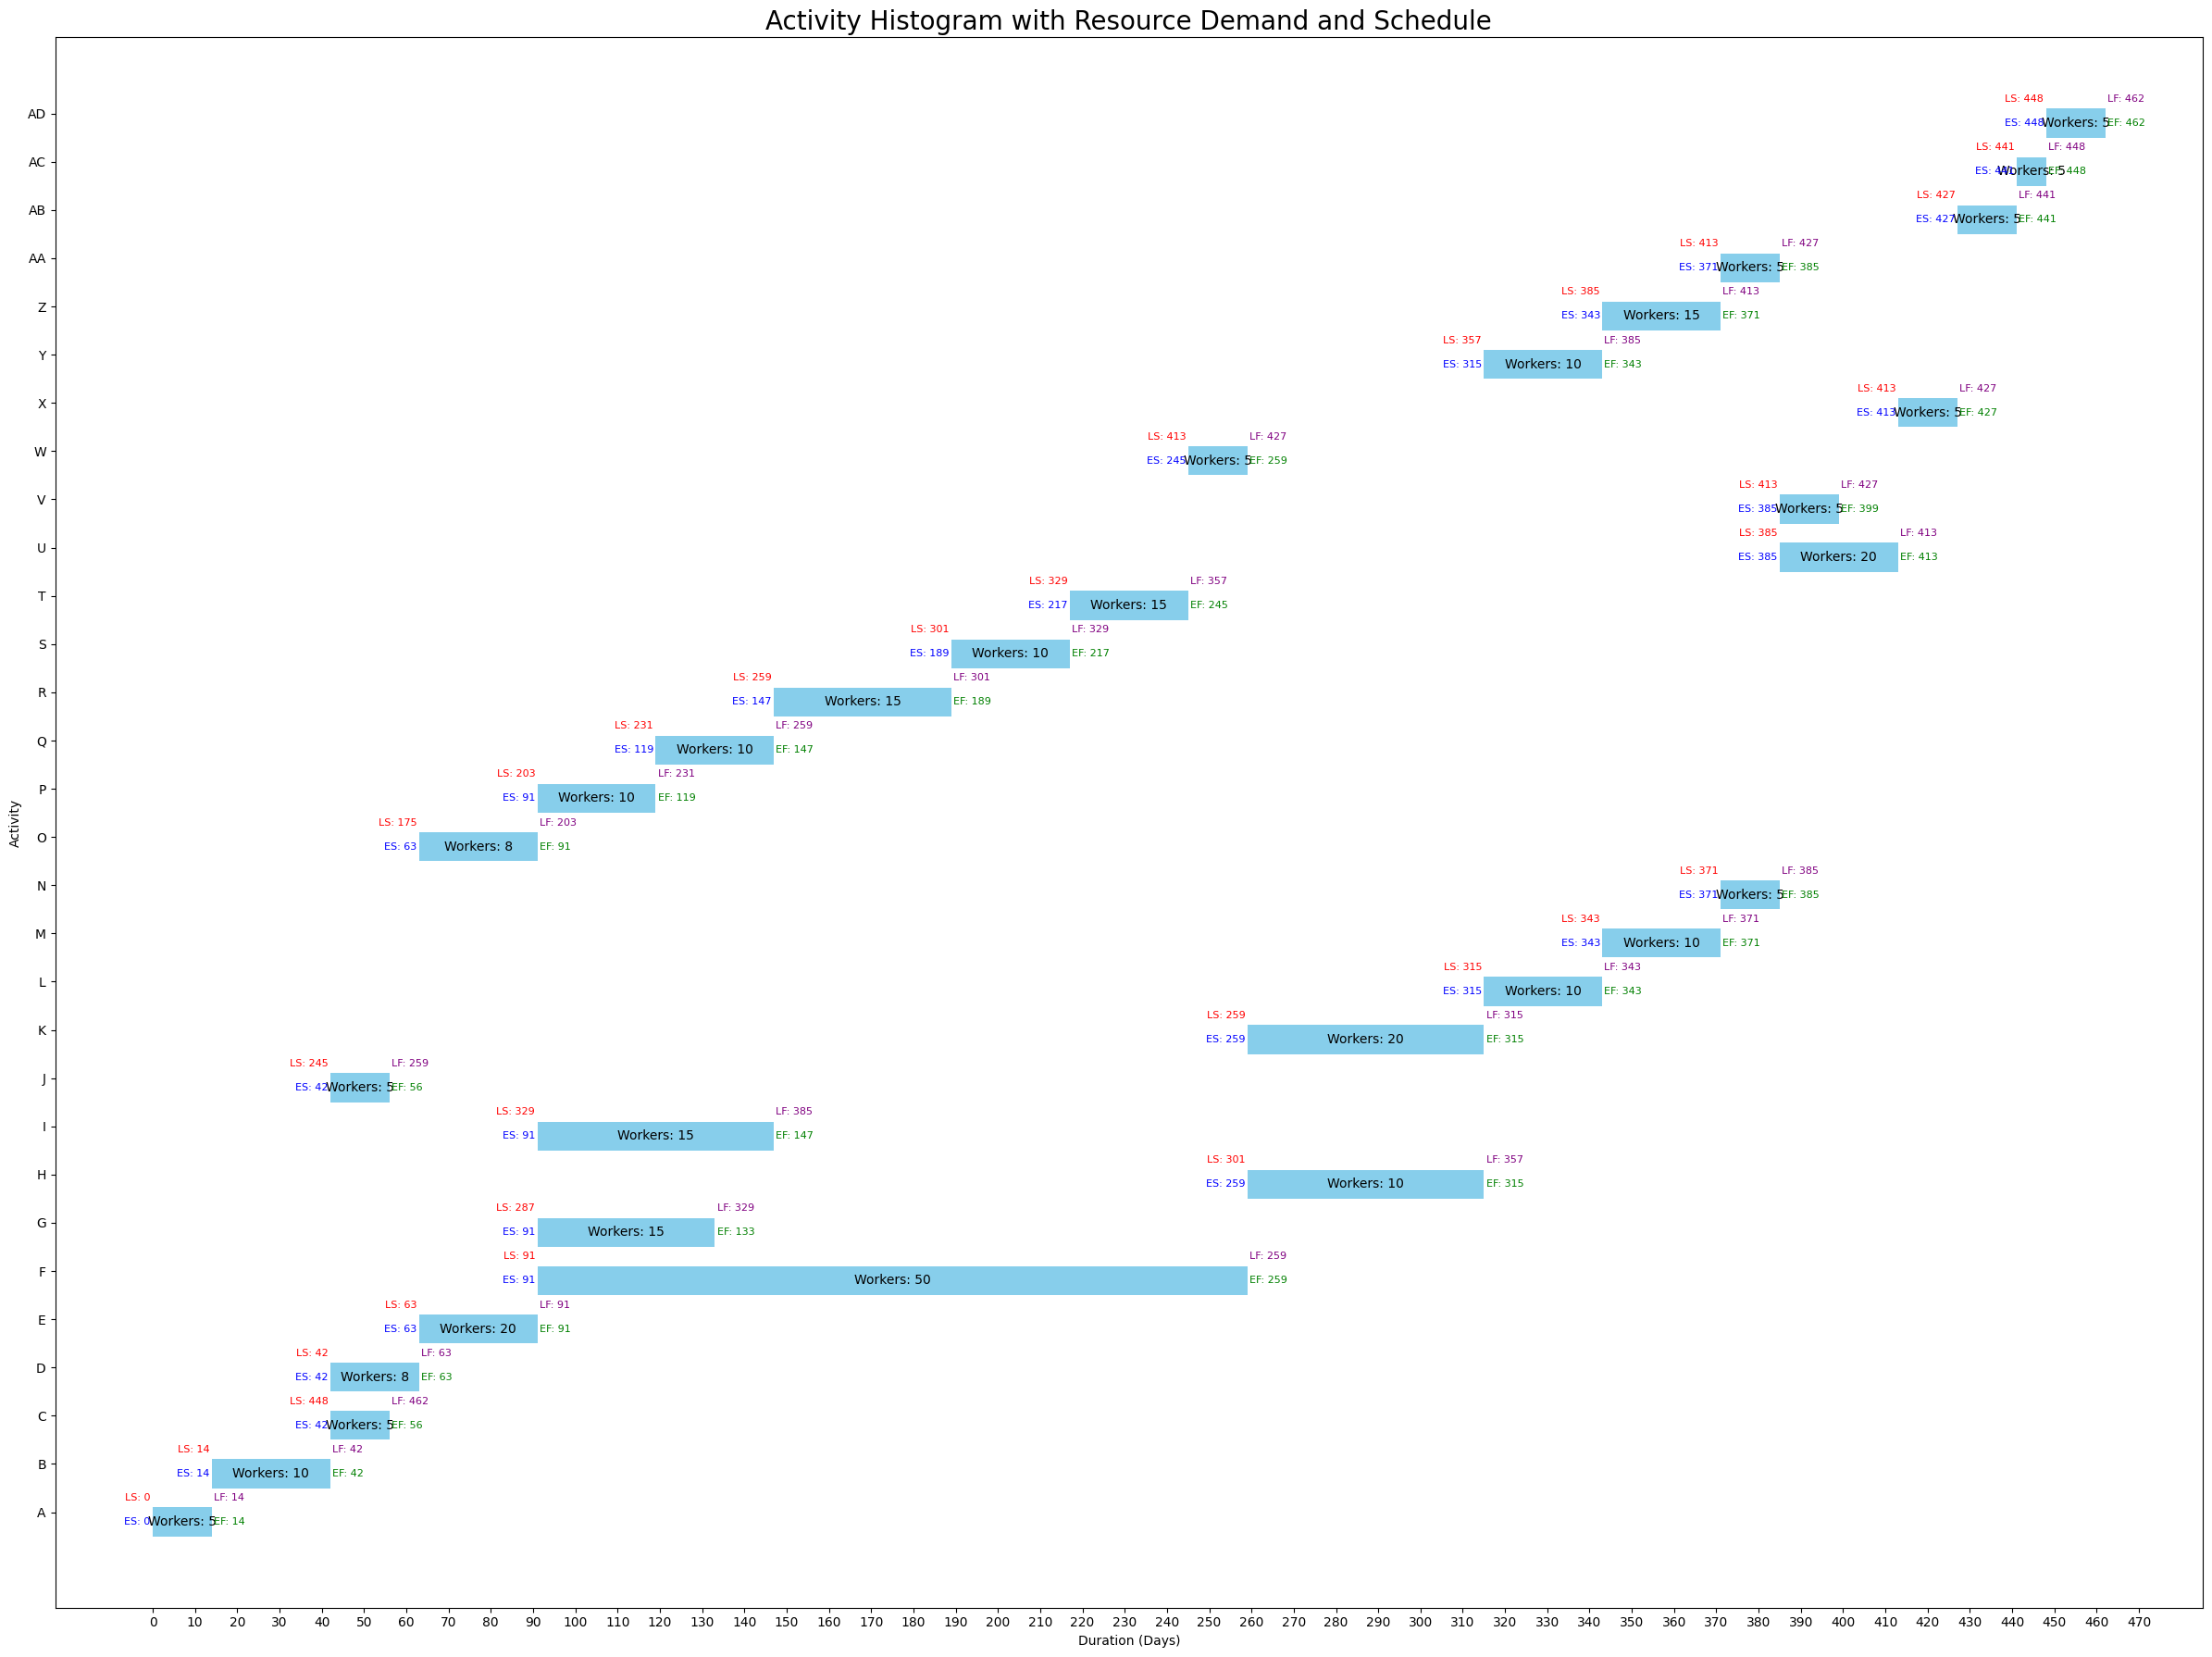

In [77]:
import matplotlib.pyplot as plt
import numpy as np

def plot_activity_histogram(activities, G,filename="activity_histogram.png"):
    # Data for plotting
    activity_names = list(activities.keys())
    durations = [G.nodes[act]['duration'] for act in activity_names]
    es_values = [G.nodes[act]['ES'] for act in activity_names]
    ef_values = [G.nodes[act]['EF'] for act in activity_names]
    ls_values = [G.nodes[act]['LS'] for act in activity_names]
    lf_values = [G.nodes[act]['LF'] for act in activity_names]
    resources = [activities[act]['resources'] for act in activity_names]


    xranges = [[(es, ef - es)] for es, ef in zip(es_values, ef_values)]
    # yrange = [(i * 1, 0.8) for i in range(len(activity_names))] #The original yrange is a list of tuples which caused the issue
    # Modified yrange to a list of tuples with a single tuple for each activity.
    yrange = [(i * 1, 0.6) for i in range(len(activity_names))]

    # Create the histogram
    fig, ax = plt.subplots(figsize=(24, 18))

    # Iterate over xranges and yrange to plot individual bars
    for i in range(len(activity_names)):
        ax.broken_barh(xranges[i], yrange[i], facecolors='skyblue') #Pass each tuple individually to broken_barh


    # Add resource demand as text within bars
    for i, resource in enumerate(resources):
        ax.text(xranges[i][0][0] + xranges[i][0][1] / 2, yrange[i][0] + yrange[i][1] / 2,
                f"Workers: {resource}", ha='center', va='center', color='black')

    # Add ES, EF, LS, LF as text annotations
    for i, (es, ef, ls, lf) in enumerate(zip(es_values, ef_values, ls_values, lf_values)):
        ax.text(es - 0.5, yrange[i][0] + yrange[i][1] / 2, f"ES: {es}", ha='right', va='center', fontsize=8, color='blue')
        ax.text(ef + 0.5, yrange[i][0] + yrange[i][1] / 2, f"EF: {ef}", ha='left', va='center', fontsize=8, color='green')
        ax.text(es - 0.5, yrange[i][0] + yrange[i][1] / 2 + 0.5, f"LS: {ls}", ha='right', va='center', fontsize=8, color='red')
        ax.text(ef + 0.5, yrange[i][0] + yrange[i][1] / 2 + 0.5, f"LF: {lf}", ha='left', va='center', fontsize=8, color='purple')


    max_duration = max(ef_values)
    ax.set_xticks(np.arange(0, max_duration + 10, 10))  # Ticks every 10 days
    ax.set_xlabel("Duration (Days)")

    # Set y-axis ticks and labels
    ax.set_yticks(np.arange(0.5, len(activity_names), 1))  # Centered on bars
    ax.set_yticklabels(activity_names)
    ax.set_ylabel("Activity")
    # Chart formatting

    ax.set_xlabel("Duration (Days)")
    ax.set_ylabel("Activity")
    ax.set_title("Activity Histogram with Resource Demand and Schedule",fontsize=20)
    plt.tight_layout()

    plt.savefig(filename, dpi=300)  # Save the figure
    print(f"Histogram saved as '{filename}'")  # Print confirmation

    plt.show()


G, critical_path, project_duration = calculate_cpm(activities) # Assuming calculate_cpm is defined
plot_activity_histogram(activities, G)



Project Duration: 462 days
Critical Path: ['A', 'B', 'D', 'E', 'F', 'K', 'L', 'M', 'N', 'U', 'X', 'AB', 'AC', 'AD']


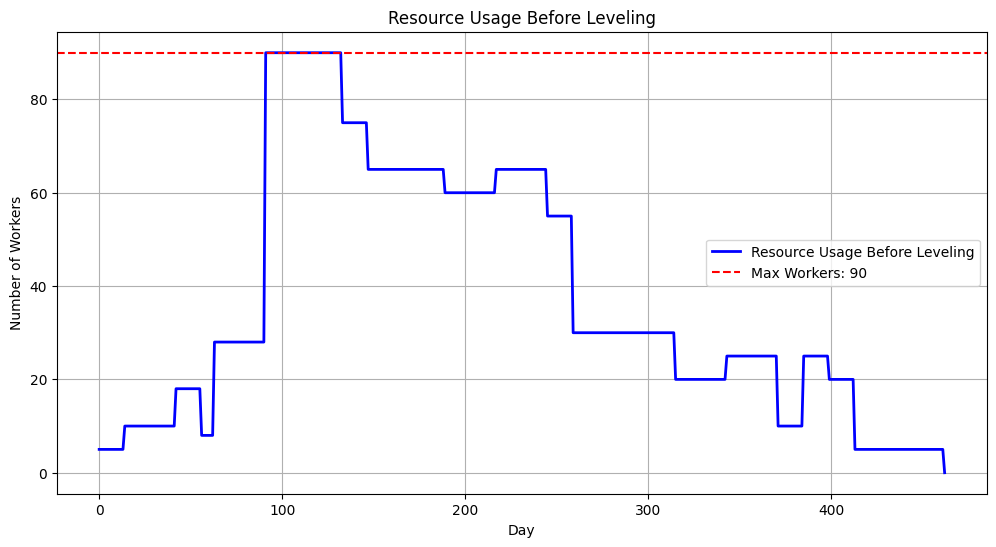

In [54]:
# Calculate resource usage before leveling
def resource_usage_before_leveling(G, activities):
    max_duration = max(G.nodes[n]['EF'] for n in G.nodes)
    resource_profile = [0] * (max_duration + 1)
    for act in activities:
        es = G.nodes[act]['ES']
        ef = G.nodes[act]['EF']
        resources = activities[act]['resources']
        for day in range(es, ef):
            resource_profile[day] += resources
    return resource_profile

# Run CPM and get resource profile before leveling
G, critical_path, project_duration = calculate_cpm(activities)
print(f"Project Duration: {project_duration} days")
print(f"Critical Path: {critical_path}")
resource_profile_before = resource_usage_before_leveling(G, activities)

# Plot resource usage before leveling
plt.figure(figsize=(12, 6))
plt.plot(range(len(resource_profile_before)), resource_profile_before, 'b-', label='Resource Usage Before Leveling', linewidth=2)
plt.axhline(max(resource_profile_before), color='r', linestyle='--', label=f'Max Workers: {max(resource_profile_before)}')
plt.xlabel('Day')
plt.ylabel('Number of Workers')
plt.title('Resource Usage Before Leveling')
plt.legend()
plt.grid(True)
plt.show()

# discussion


New Project Duration: 462 days


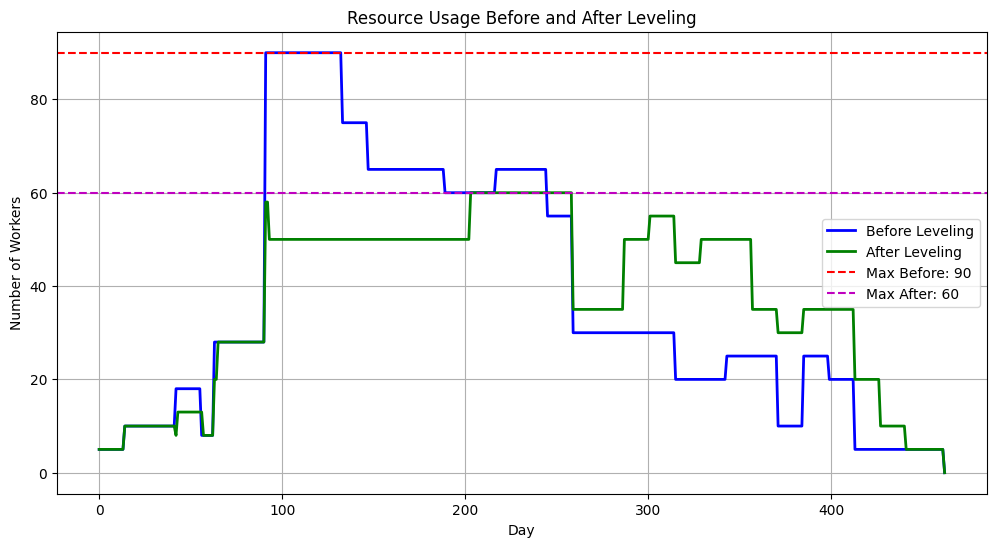

Resource Leveling:
   - Before resource leveling, the maximum resource demand was: 90 workers
   - After resource leveling, the maximum resource demand is reduced to: 60 workers
   - This reduction in peak resource demand was achieved by strategically shifting non-critical activities within their available float (slack).
   - By delaying the start of certain non-critical activities, resource usage was spread out more evenly over time.
   - This prevented the concentration of resource demand at specific periods, which would have required a larger workforce.
   - The leveling process ensured that the project could be completed with a smaller maximum workforce of 60 workers without extending the project duration.
   - This leads to better resource allocation, cost savings, and improved project feasibility.


In [84]:

import numpy as np

# Resource leveling function
def resource_leveling(activities, G, max_resources=60):
    leveled_activities = activities.copy()
    # Calculate float for each activity
    for act in leveled_activities:
        ef = G.nodes[act]['EF']
        lf = G.nodes[act]['LF']
        leveled_activities[act]['float'] = lf - ef

    # Level resources by delaying non-critical activities
    new_G = nx.DiGraph()
    for act, info in leveled_activities.items():
        new_G.add_node(act, duration=info['normal_duration'], resources=info['resources'])
        for dep in info['depends']:
            new_G.add_edge(dep, act)

    # Initial ES and EF
    for node in nx.topological_sort(new_G):
        predecessors = list(new_G.predecessors(node))
        if not predecessors:
            new_G.nodes[node]['ES'] = 0
            new_G.nodes[node]['EF'] = new_G.nodes[node]['duration']
        else:
            new_G.nodes[node]['ES'] = max(new_G.nodes[pred]['EF'] for pred in predecessors)
            new_G.nodes[node]['EF'] = new_G.nodes[node]['ES'] + new_G.nodes[node]['duration']

    # Calculate initial LF and LS before adjusting (This is the key fix)
    end_nodes = [n for n, d in new_G.out_degree() if d == 0]
    project_duration = max(new_G.nodes[n]['EF'] for n in end_nodes)
    for node in reversed(list(nx.topological_sort(new_G))):
        successors = list(new_G.successors(node))
        if not successors:
            new_G.nodes[node]['LF'] = project_duration
            new_G.nodes[node]['LS'] = new_G.nodes[node]['LF'] - new_G.nodes[node]['duration']
        else:
            new_G.nodes[node]['LF'] = min(new_G.nodes[succ]['LS'] for succ in successors)
            new_G.nodes[node]['LS'] = new_G.nodes[node]['LF'] - new_G.nodes[node]['duration']

    # Adjust non-critical activities
    changed = True


# New logic inside the while loop
    while changed:
        changed = False
        resource_profile = resource_usage_before_leveling(new_G, leveled_activities)
        variance_before = np.var(resource_profile)

        # Try delaying non-critical activities with float > 0
        for act in sorted(leveled_activities, key=lambda x: -leveled_activities[x]['float']):  # Higher float first
            if leveled_activities[act]['float'] > 0:
                current_es = new_G.nodes[act]['ES']
                max_delay = leveled_activities[act]['float']
                best_es = current_es
                best_variance = variance_before

                for delay in range(1, max_delay + 1):
                    trial_es = current_es + delay
                    if trial_es > new_G.nodes[act]['LF'] - new_G.nodes[act]['duration']:
                        continue

                    # Temporarily shift activity
                    temp_G = new_G.copy()
                    temp_G.nodes[act]['ES'] = trial_es
                    temp_G.nodes[act]['EF'] = trial_es + temp_G.nodes[act]['duration']

                    # Shift successors
                    for succ in nx.descendants(temp_G, act):
                        preds = list(temp_G.predecessors(succ))
                        temp_G.nodes[succ]['ES'] = max(temp_G.nodes[p]['EF'] for p in preds)
                        temp_G.nodes[succ]['EF'] = temp_G.nodes[succ]['ES'] + temp_G.nodes[succ]['duration']

                    # Recalculate resource profile
                    temp_profile = resource_usage_after_leveling(temp_G, leveled_activities)
                    temp_variance = np.var(temp_profile)

                    if temp_variance < best_variance:
                        best_es = trial_es
                        best_variance = temp_variance
                        changed = True

                if best_es != current_es:
                    new_G.nodes[act]['ES'] = best_es
                    new_G.nodes[act]['EF'] = best_es + new_G.nodes[act]['duration']
                    for succ in nx.descendants(new_G, act):
                        preds = list(new_G.predecessors(succ))
                        new_G.nodes[succ]['ES'] = max(new_G.nodes[p]['EF'] for p in preds)
                        new_G.nodes[succ]['EF'] = new_G.nodes[succ]['ES'] + new_G.nodes[succ]['duration']

        if not changed:
            break


    # Recalculate backward pass to ensure feasibility
    end_nodes = [n for n, d in new_G.out_degree() if d == 0]
    project_duration = max(new_G.nodes[n]['EF'] for n in end_nodes)
    for node in reversed(list(nx.topological_sort(new_G))):
        successors = list(new_G.successors(node))
        if not successors:
            new_G.nodes[node]['LF'] = project_duration
            new_G.nodes[node]['LS'] = new_G.nodes[node]['LF'] - new_G.nodes[node]['duration']
        else:
            new_G.nodes[node]['LF'] = min(new_G.nodes[succ]['LS'] for succ in successors)
            new_G.nodes[node]['LS'] = new_G.nodes[node]['LF'] - new_G.nodes[node]['duration']

    return new_G, project_duration

# Calculate resource usage after leveling
def resource_usage_after_leveling(new_G, activities):
    max_duration = max(new_G.nodes[n]['EF'] for n in new_G.nodes)
    resource_profile = [0] * (max_duration + 1)
    for act in activities:
        es = new_G.nodes[act]['ES']
        ef = new_G.nodes[act]['EF']
        resources = activities[act]['resources']
        for day in range(es, ef):
            resource_profile[day] += resources
    return resource_profile

# Perform leveling and get new profiles
new_G, new_project_duration = resource_leveling(activities, G)
resource_profile_after = resource_usage_after_leveling(new_G, activities)
print(f"New Project Duration: {new_project_duration} days")

# Plot both resource usages
plt.figure(figsize=(12, 6))
plt.plot(range(len(resource_profile_before)), resource_profile_before, 'b-', label='Before Leveling', linewidth=2)
plt.plot(range(len(resource_profile_after)), resource_profile_after, 'g-', label='After Leveling', linewidth=2)
plt.axhline(max(resource_profile_before), color='r', linestyle='--', label=f'Max Before: {max(resource_profile_before)}')
plt.axhline(max(resource_profile_after), color='m', linestyle='--', label=f'Max After: {max(resource_profile_after)}')
plt.xlabel('Day')
plt.ylabel('Number of Workers')
plt.title('Resource Usage Before and After Leveling')
plt.legend()
plt.grid(True)
plt.show()

#  Resource Leveling:
print("Resource Leveling:")
print(f"   - Before resource leveling, the maximum resource demand was: {max(resource_profile_before)} workers")
print(f"   - After resource leveling, the maximum resource demand is reduced to: {max(resource_profile_after)} workers")
print("   - This reduction in peak resource demand was achieved by strategically shifting non-critical activities within their available float (slack).")
print("   - By delaying the start of certain non-critical activities, resource usage was spread out more evenly over time.")
print("   - This prevented the concentration of resource demand at specific periods, which would have required a larger workforce.")
print("   - The leveling process ensured that the project could be completed with a smaller maximum workforce of 60 workers without extending the project duration.")
print("   - This leads to better resource allocation, cost savings, and improved project feasibility.")